# Custom CNN architecture and training

Select the repository .venv kernel and run cells in order. Uses the fixed shared split and reusable src modules. Full training requires enabling its cell explicitly.


In [2]:
from pathlib import Path
import sys

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "dataset").is_dir() and (p / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook inside the project repository.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Repository:", ROOT)


Repository: /Users/keerthikeerthi/Desktop/brain-tumor-mri-classification


## Architecture
The implementation lives in `src/model.py` and is imported below.

RGB 224×224 input → training augmentation → convolution blocks with 32, 64, 128, and 256 filters → global average pooling → Dense(256, ReLU) → Dropout(0.5) → Dense(4, softmax).

Blocks use batch normalization, 2×2 max pooling, and dropout. Adam starts at 0.001; sparse categorical cross-entropy matches integer manifest labels. Inputs are already normalized by the data pipeline.


In [3]:
import tensorflow as tf



In [4]:
from src.model import build_model, SEED


## Run the check


In [6]:
from src.data_pipeline import make_dataset

tf.keras.utils.set_random_seed(SEED)
model = build_model()
model.summary()

# Verify inference using two training images.
images, labels = next(iter(make_dataset("train")))
probabilities = model(images[:2], training=False)

tf.debugging.assert_shapes([(probabilities, (2, 4))])
tf.debugging.assert_all_finite(
    probabilities, "Model produced invalid probabilities"
)
tf.debugging.assert_near(
    tf.reduce_sum(probabilities, axis=1),
    tf.ones(2),
    atol=1e-5,
)

print("\nOutput shape:", probabilities.shape)
print("Probability sums:", tf.reduce_sum(probabilities, axis=1).numpy())
print("Model check completed. Training has not started.")

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn (BatchNormalization)  │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dropout (Dropout)        │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn (BatchNormalization)  │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn (BatchNormalization)  │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_dropout (Dropout)        │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv (Conv2D)            │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_bn (BatchNormalization)  │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_dropout (Dropout)        │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pool                     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 650,916 (2.48 MB)

 Trainable params: 649,956 (2.48 MB)

 Non-trainable params: 960 (3.75 KB)


Output shape: (2, 4)
Probability sums: [1. 1.]
Model check completed. Training has not started.


## Training
Run the short check first. Full training is disabled by default; enable it after checking runtime. Each run creates fresh weights and separate output folders. Test data is never loaded here.


In [7]:
from src.training import train_cnn

smoke_run = train_cnn(smoke_test=True)


/Users/keerthikeerthi/Desktop/brain-tumor-mri-classification/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.3281 - loss: 1.5598 - val_accuracy: 0.8906 - val_loss: 1.3818 - learning_rate: 0.0010
Completed in 4.2s. Results: /Users/keerthikeerthi/Desktop/brain-tumor-mri-classification/results/smoke_20260928T043649788409Z
Checkpoint reload passed. Test set was not used.


## Full training
Set RUN_FULL_TRAINING to True when ready. The best checkpoint uses validation loss. A full run starts fresh, not from the short check. Do not interpret short-check accuracy as a final result.


In [8]:
RUN_FULL_TRAINING = True

if RUN_FULL_TRAINING:
    full_run = train_cnn(smoke_test=False, epochs=50)
else:
    print("Full training disabled. Review the short check first.")


Full training disabled. Review the short check first.


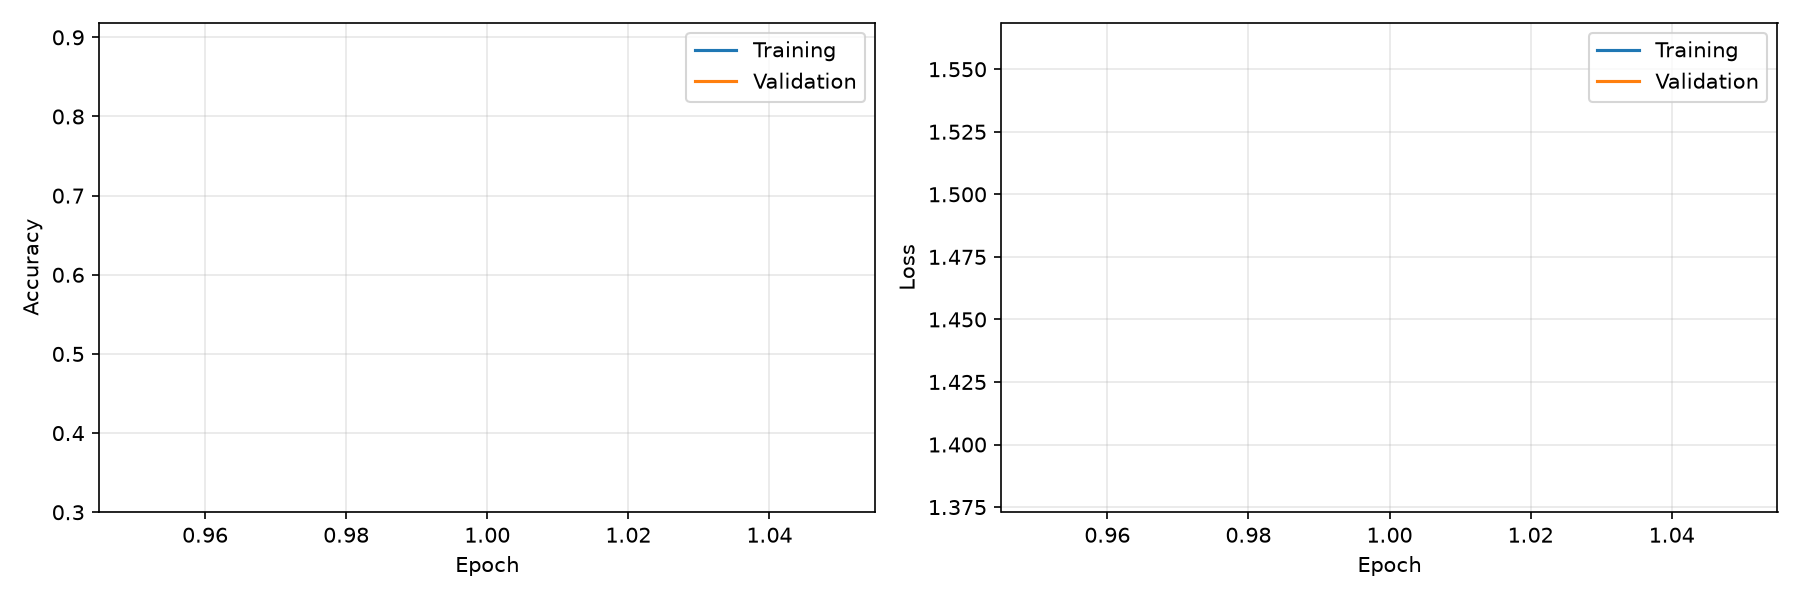

{'training_seconds': 4.206609832996037, 'epochs_completed': 1, 'best_epoch': 1, 'best_validation_loss': 1.3818353414535522, 'checkpoint': 'models/smoke_20260928T043649788409Z/best.keras', 'checkpoint_reload_passed': True}


In [9]:
from IPython.display import Image, display

run = full_run if RUN_FULL_TRAINING else smoke_run
display(Image(filename=str(run["output_dir"] / "learning_curves.png")))
print(run["summary"])
